In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")
df.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns


Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")
df.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns


Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')

In [7]:
date_cols = [c for c in df.columns if "date" in c or "year" in c]
date_cols

date_col = date_cols[0]
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df["year"] = df[date_col].dt.year


In [8]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

value_col = numeric_cols[0]
print("Forecasting column:", value_col)


Forecasting column: value_numeric


In [9]:
yearly = (
    df.groupby("year")[value_col]
    .mean()
    .reset_index()
    .dropna()
)

yearly.head()


,year,value_numeric
0,2014.0,2.200000e+01
1,2017.0,3.500000e+01
2,2021.0,3.254000e+01
4,2023.0,3.750000e+01
5,2024.0,6.872744e+06


In [10]:
X = yearly[["year"]]
y = yearly[value_col]

model = LinearRegression()
model.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
last_year = int(yearly["year"].max())

future_years = pd.DataFrame({
    "year": range(last_year + 1, last_year + 6)
})

future_years


,year
0,2031
1,2032
2,2033
3,2034
4,2035


In [13]:
future_years["forecast"] = model.predict(future_years[["year"]])
future_years


,year,forecast
0,2031,5.661706e+10
1,2032,5.954629e+10
2,2033,6.247551e+10
3,2034,6.540474e+10
4,2035,6.833396e+10


In [14]:
forecast_df = pd.concat([
    yearly.rename(columns={value_col: "value"}),
    future_years.rename(columns={"forecast": "value"})
])

forecast_df["type"] = (
    ["historical"] * len(yearly) +
    ["forecast"] * len(future_years)
)

forecast_df


,year,value,type
0,2014.0,2.200000e+01,historical
1,2017.0,3.500000e+01,historical
2,2021.0,3.254000e+01,historical
4,2023.0,3.750000e+01,historical
5,2024.0,6.872744e+06,historical
6,2025.0,2.595108e+11,historical
7,2028.0,9.000000e+07,historical
8,2030.0,5.000000e+01,historical
0,2031.0,5.661706e+10,forecast
1,2032.0,5.954629e+10,forecast


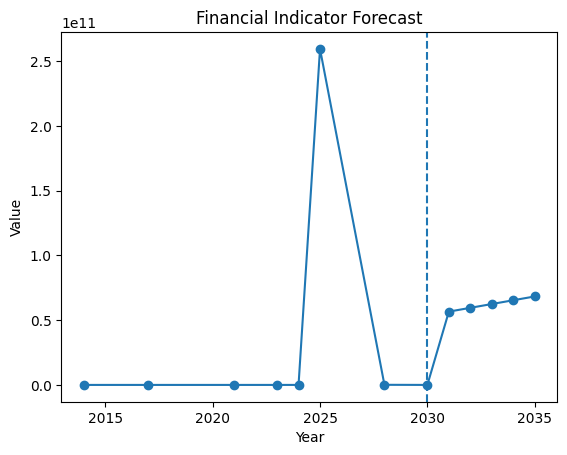

In [15]:
plt.figure()
plt.plot(forecast_df["year"], forecast_df["value"], marker="o")
plt.axvline(last_year, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Financial Indicator Forecast")
plt.show()


In [16]:
forecast_df.to_csv(
    "../data/processed/task_4_forecast_results.csv",
    index=False
)

print("Task 4 forecast saved successfully")


Task 4 forecast saved successfully
